## 1. Configuration and Setup

This section initializes the environment and defines all constants required to **train the Transformer-based lip-reading model** on the **LRS2 dataset**. It handles hardware detection, dataset paths, token mappings, and training hyperparameters.

---

### Purpose
- Configure the notebook for **training the Transformer model** on LRS2 data.
- Handle **dynamic GPU-based settings** (batch size, learning rate, RAM buffer).
- Define **tokens, visemes, and phoneme mappings** needed by the model.
- Prepare **dataset paths** for reading preprocessed batches.

---

### Dataset Format
- The **LRS2 dataset** is preprocessed and **saved as compressed `.npz` files**.
- Each `.npz` file contains **32 videos with corresponding viseme sequences**.
- This batching format enables **efficient streaming into RAM** during training.

---

### Key Components

#### 1. Library Imports
- Core Python utilities: `os`, `math`, `time`, `random`, `gc`
- Deep learning: `torch`, `torch.nn`, `torch.utils.data`
- Data processing: `numpy`
- Progress tracking: `tqdm`

#### 2. Device and GPU Setup
- Checks for GPU availability via `torch.cuda.is_available()`.
- Prints GPU name and available VRAM.
- Dynamically configures:
  - **Batch size**
  - **Learning rate**
  - **RAM buffer size** (how many `.npz` batches to load into memory)

#### 3. Google Drive Mounting
- Mounts Google Drive at `/content/drive` for:
  - Loading `.npz` training batches.
  - Saving model checkpoints after each epoch.

#### 4. Token and Viseme Definitions
- Defines **viseme tokens** (mouth-shape units) and **special tokens**:
  - `<sos>`, `<eos>`, `<sow>`, `<eow>`, `<space>`, `<pad>`
- Creates mappings:
  - `TOKEN_TO_INDEX` (token → integer index)
  - `INDEX_TO_TOKEN` (index → token)
- Builds **viseme ↔ phoneme** dictionaries for decoding predictions.

#### 5. Model Hyperparameters
- `MAX_FRAMES = 250` (max frames per video sequence)
- `FEATURE_DIM = 512` (visual feature size)
- `MAX_SEQ_LEN = 250` (max tokenized sequence length)
- Vocabulary size = total viseme + special tokens.

#### 6. Dataset Split
- Total videos: **80,000**
- `.npz` batch files: **32 videos per file → 2,500 files total**
- Split: **90% train / 10% validation**
- Computes training and validation batch counts automatically.

---

### Outcome
After this setup:
- The notebook knows **where to load data, how it’s batched, and token structure**.
- Dynamic settings adapt to GPU type (e.g., **A100** vs **L4**).
- Ready for **data loading, model building, and training** phases.


In [1]:
# === 📦 Standard Libraries ===
import os
import math
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import gc
import random
from tqdm import tqdm

# === ⚙️ Device Configuration & GPU Info ===
if torch.cuda.is_available():
    device = torch.device("cuda")
    gpu_name = torch.cuda.get_device_name(0)
    total_mem_bytes = torch.cuda.get_device_properties(0).total_memory
    total_mem_gb = round(total_mem_bytes / (1024**3), 2)
    print(f"✅ GPU detected: {gpu_name} with {total_mem_gb} GB VRAM")
else:
    device = torch.device("cpu")
    print("⚠️ No GPU detected. Using CPU.")



# === 🧠 Dynamic Training Configuration ===
if "l4" in gpu_name:
    print("🧠 Detected L4 GPU → Using lightweight config")
    BATCH_SIZE = 64
    LEARNING_RATE = 1.5e-4
    RAM_BUFFER_SIZE_GB = 30
elif "A100" in gpu_name:
    print("🚀 Detected A100 GPU → Using full config")
    BATCH_SIZE = 96
    LEARNING_RATE = (1.5e-4)*1.5
    RAM_BUFFER_SIZE_GB = 60
else:
    print("⚠️ Unknown GPU → Defaulting to L4-like settings")
    BATCH_SIZE = 64
    LEARNING_RATE = 1.5e-4
    RAM_BUFFER_SIZE_GB = 30


# === 📁 Mount Google Drive for data access ===
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

# === 📍 Global Paths ===
BATCH_FOLDER = "/content/drive/My Drive/majd/pretrain_data_batches_ready_to_load"
MODEL_SAVE_FOLDER = "/content/drive/My Drive/majd/Viso_Speak_model"
os.makedirs(MODEL_SAVE_FOLDER, exist_ok=True)

# === 🔁 RAM Buffer Settings ===
#RAM_BUFFER_SIZE_GB =  60   # Target RAM usage for preloaded batches

# === 🔤 Viseme & Token Definitions ===
VISEME_TOKENS  = [
    "AA", "AE", "AH", "AO", "AW", "AY",
    "B", "CH", "D", "DH", "EH", "ER",
    "EY", "F", "G", "HH", "IH", "IY",
    "JH", "K", "L", "M", "N", "NG",
    "OW", "OY", "P", "R", "S", "SH",
    "T", "TH", "UH", "UW", "V", "W",
    "Y", "Z", "ZH", "sil", "<unk>"
]

SPECIAL_TOKENS = ["<sos>", "<eos>", "<sow>", "<eow>", "<space>", "<sil>", "<pad>"]
ALL_TOKENS = SPECIAL_TOKENS + VISEME_TOKENS

TOKEN_TO_INDEX = {tok: idx for idx, tok in enumerate(ALL_TOKENS)}
INDEX_TO_TOKEN = {idx: tok for tok, idx in TOKEN_TO_INDEX.items()}

viseme_to_phonemes = {
    "AA": ["AA", "AA0", "AA1", "AA2"], "AE": ["AE", "AE0", "AE1", "AE2"],
    "AH": ["AH", "AH0", "AH1", "AH2"], "AO": ["AO", "AO0", "AO1", "AO2"],
    "AW": ["AW", "AW0", "AW1", "AW2"], "AY": ["AY", "AY0", "AY1", "AY2"],
    "B": ["B"], "CH": ["CH"], "D": ["D"], "DH": ["DH"],
    "EH": ["EH", "EH0", "EH1", "EH2"], "ER": ["ER", "ER0", "ER1", "ER2"],
    "EY": ["EY", "EY0", "EY1", "EY2"], "F": ["F"], "G": ["G"], "HH": ["HH"],
    "IH": ["IH", "IH0", "IH1", "IH2"], "IY": ["IY", "IY0", "IY1", "IY2"],
    "JH": ["JH"], "K": ["K"], "L": ["L"], "M": ["M"], "N": ["N"],
    "NG": ["NG"], "OW": ["OW", "OW0", "OW1", "OW2"], "OY": ["OY", "OY0", "OY1", "OY2"],
    "P": ["P"], "R": ["R"], "S": ["S"], "SH": ["SH"], "T": ["T"],
    "TH": ["TH"], "UH": ["UH", "UH0", "UH1", "UH2"], "UW": ["UW", "UW0", "UW1", "UW2"],
    "V": ["V"], "W": ["W"], "Y": ["Y"], "Z": ["Z"], "ZH": ["ZH"],
    "sil": ["sil"], "unk": ["unk"]
}

phoneme_to_viseme = {}
for viseme, phonemes in viseme_to_phonemes.items():
    for phoneme in phonemes:
        phoneme_to_viseme[phoneme] = viseme

# === 🧠 Model Hyperparameters ===
MAX_FRAMES = 250
FEATURE_DIM = 512
MAX_SEQ_LEN = 250

# === 🔢 Token IDs
VOCAB_SIZE = len(ALL_TOKENS)
PAD_IDX = TOKEN_TO_INDEX["<pad>"]
SOS_IDX = TOKEN_TO_INDEX["<sos>"]
EOS_IDX = TOKEN_TO_INDEX["<eos>"]

# === 🏋️ Training Config ===
#BATCH_SIZE = 128
#LEARNING_RATE = 2e-4
NUM_EPOCHS = 100


# === 📊 Dataset Split (based on 80,000 videos) ===
TOTAL_VIDEOS = 80000
VIDEOS_PER_FILE = 32  # each .npz file holds 32 videos
FILES_NEEDED = TOTAL_VIDEOS // VIDEOS_PER_FILE  # 2500 files needed

SAMPLES_PER_BATCH = BATCH_SIZE
TOTAL_BATCHES = TOTAL_VIDEOS // SAMPLES_PER_BATCH  # 1250 batches

VAL_SPLIT = 0.10
VAL_BATCHES = int(TOTAL_BATCHES * VAL_SPLIT)       # 125
TRAIN_BATCHES = TOTAL_BATCHES - VAL_BATCHES        # 1125

early_stop_patience = 3

print(f"📊 TOTAL_VIDEOS = {TOTAL_VIDEOS} | BATCH_SIZE = {BATCH_SIZE}")
print(f"Batch Size= {BATCH_SIZE}")
print(f"📂 .npz FILES NEEDED = {FILES_NEEDED}")
print(f"📦 Total Batches = {TOTAL_BATCHES} → Train: {TRAIN_BATCHES}, Validation: {VAL_BATCHES}")
print(f"🧠 Buffer Target: {RAM_BUFFER_SIZE_GB} GB of RAM usage")

print(VOCAB_SIZE)

✅ GPU detected: NVIDIA A100-SXM4-40GB with 39.56 GB VRAM
🚀 Detected A100 GPU → Using full config
Mounted at /content/drive
📊 TOTAL_VIDEOS = 80000 | BATCH_SIZE = 96
Batch Size= 96
📂 .npz FILES NEEDED = 2500
📦 Total Batches = 833 → Train: 750, Validation: 83
🧠 Buffer Target: 60 GB of RAM usage
48


## 2. Model Architecture: Visual Frontend + Transformer

This section defines the **lip-reading model** used to predict viseme sequences from silent video input.  
The architecture follows a **sequence-to-sequence Transformer approach** with three main components:

1. **Visual Frontend (3D CNN)** – Extracts spatiotemporal features from video frames.
2. **Transformer Encoder** – Captures temporal dependencies across the extracted features.
3. **Transformer Decoder** – Generates viseme tokens autoregressively using encoder outputs as context.

---

### 2.1 Visual Frontend (3D CNN)

**Purpose**:  
- Process raw video frames (`T x H x W`) and extract meaningful spatiotemporal features.
- Reduce spatial dimensions while preserving temporal information.

**Key Details**:
- Input shape: `(Batch, Time, Height, Width, 1)` → grayscale frames.
- Four 3D convolution layers (`Conv3d`) with increasing channels: **1→32→64→128→256**.
- Stride and kernel sizes progressively downsample spatial resolution.
- `AdaptiveAvgPool3d` ensures fixed temporal length (`MAX_FRAMES`) regardless of input video size.
- Final `Linear` layer projects features to **512-dim** (set by `FEATURE_DIM`).

Output: `(Batch, Time, 512)` – feature sequence for the encoder.

---

### 2.2 Transformer Encoder

**Purpose**:  
- Model **temporal relationships** across extracted features (lip motion over time).  
- Provide **contextualized representations** for each time step.

**Key Details**:
- Built using `nn.TransformerEncoder` with **multi-head self-attention**.
- 4 stacked encoder layers, 8 attention heads, and a feed-forward network size of **2048**.
- Processes the 3D CNN output and outputs **context-aware feature sequences**.

Output: `(Batch, Time, 512)` – contextual memory for the decoder.

---

### 2.3 Transformer Decoder

**Purpose**:  
- Generate viseme tokens sequentially (autoregressive prediction).
- Use encoder memory (visual context) + previously predicted tokens to predict the next token.

**Key Details**:
- Embedding layer converts token IDs to **512-dim vectors**.
- `nn.TransformerDecoder` with 4 layers, 8 attention heads, dropout 0.4.
- Uses **causal masking** (`generate_square_subsequent_mask`) to prevent future token leakage.
- Final linear layer maps decoder outputs to the viseme vocabulary (`VOCAB_SIZE`).

Output: `(Batch, SeqLen, VOCAB_SIZE)` – logits for viseme token prediction.

---

### 2.4 Full Lip Reading Model

**Integration**:
- Combines all three components into `LipReadingModel`.
- **Forward pass flow**:
  1. Video → **Visual Frontend** → Feature sequence `(B, T, 512)`
  2. Features → **Transformer Encoder** → Context memory `(B, T, 512)`
  3. Memory + Viseme tokens → **Transformer Decoder** → Predicted logits `(B, L, vocab_size)`

---

### Notes
- Designed for **silent lip-reading**: input is video only (no audio).  
- Vocabulary includes **viseme tokens + special tokens** (`<sos>`, `<eos>`, `<pad>`).  
- Works with **LRS2 preprocessed batches** (32 videos per `.npz`).  


In [2]:
import torch.nn as nn
import torch.nn.functional as F

# === 📦 Visual Frontend: 3D CNN ===
class VisualFrontend3DCNN(nn.Module):
    def __init__(self, output_dim=FEATURE_DIM):
        super().__init__()
        self.conv1 = nn.Conv3d(1, 32, kernel_size=(3,5,5), stride=(1,2,2), padding=(1,2,2))
        self.conv2 = nn.Conv3d(32, 64, kernel_size=(3,3,3), stride=(1,2,2), padding=1)
        self.conv3 = nn.Conv3d(64, 128, kernel_size=(3,3,3), stride=(1,2,2), padding=1)
        self.conv4 = nn.Conv3d(128, 256, kernel_size=(3,3,3), stride=(1,2,2), padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.AdaptiveAvgPool3d((MAX_FRAMES, 1, 1))
        self.fc = nn.Linear(256, output_dim)

    def forward(self, x):  # x: (B, T, H, W, 1)
        x = x.permute(0, 4, 1, 2, 3)  # (B, 1, T, H, W)
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.relu(self.conv3(x))
        x = self.relu(self.conv4(x))
        x = self.pool(x)  # (B, 256, T, 1, 1)
        x = x.squeeze(-1).squeeze(-1).permute(0, 2, 1)  # (B, T, 256)
        return self.fc(x)  # (B, T, output_dim)

# === 🔁 Transformer Encoder ===
class TransformerEncoder(nn.Module):
    def __init__(self, input_dim=FEATURE_DIM, n_heads=8, num_layers=4, ff_dim=2048, dropout=0.5):
        super().__init__()
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=input_dim, nhead=n_heads, dim_feedforward=ff_dim, dropout=dropout, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    def forward(self, x):  # x: (B, T, D)
        return self.encoder(x)

# === 🔁 Transformer Decoder ===
class VisemeTransformerDecoder(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, emb_dim=FEATURE_DIM, num_layers=4, n_heads=8, ff_dim=2048, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=emb_dim, nhead=n_heads, dim_feedforward=ff_dim, dropout=dropout, batch_first=True
        )
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        self.fc_out = nn.Linear(emb_dim, vocab_size)

    def forward(self, memory, tgt_tokens):  # memory: (B, T, D), tgt_tokens: (B, L)
        tgt_emb = self.embedding(tgt_tokens)  # (B, L, D)
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(tgt_emb.size(1)).to(tgt_emb.device)
        output = self.decoder(tgt=tgt_emb, memory=memory, tgt_mask=tgt_mask)
        return self.fc_out(output)  # (B, L, vocab_size)

# === 🧠 Full Lip Reading Model ===
class LipReadingModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.visual = VisualFrontend3DCNN()
        self.encoder = TransformerEncoder()
        self.decoder = VisemeTransformerDecoder()

    def forward(self, video, viseme_input):  # video: (B, T, H, W, 1), viseme_input: (B, L)
        features = self.visual(video)              # (B, T, D)
        memory = self.encoder(features)            # (B, T, D)
        logits = self.decoder(memory, viseme_input)  # (B, L, vocab_size)
        return logits


## 3. Utility Functions and Batch Loader

This section defines helper functions used during training and evaluation of the Transformer-based lip-reading model. These include **accuracy calculation**, **token decoding**, and **loading preprocessed `.npz` batches** from Google Drive.

---

### 3.1 Accuracy Calculation

**Function:** `compute_accuracy(pred, target, pad_idx=PAD_IDX)`

**Purpose:**
- Computes **token-level accuracy** between model predictions and ground truth.
- Ignores `<pad>` tokens to avoid skewing accuracy.

**Process:**
1. Convert model logits to predicted token indices using `argmax`.
2. Create a mask to exclude `<pad>` indices.
3. Count matching tokens where the mask is `True`.
4. Return accuracy as `(correct tokens / total non-pad tokens)`.

---

### 3.2 Token Decoder

**Function:** `decode_token_sequence(indices)`

**Purpose:**
- Converts token indices back into **readable viseme or special tokens**.
- Uses the `INDEX_TO_TOKEN` mapping defined in the configuration.

**Example:**
```python
decode_token_sequence([2, 5, 6])
# Output: ['<sos>', 'B', 'AE']


In [3]:
import os
import torch
import numpy as np

# === 📌 Accuracy Function ===
def compute_accuracy(pred, target, pad_idx=PAD_IDX):
    """
    Computes token-level accuracy, ignoring <pad> tokens.
    """
    pred_tokens = pred.argmax(dim=-1)
    mask = target != pad_idx
    correct = (pred_tokens == target) & mask
    return correct.sum().item() / mask.sum().item()

# === 🧾 Token Decoder ===
def decode_token_sequence(indices):
    return [INDEX_TO_TOKEN.get(idx, "?") for idx in indices]



### Batch Loader

**Function:** `load_and_prepare_batch(batch_index)`

**Purpose**  
- Loads preprocessed **compressed batches** of the LRS2 dataset (videos + viseme labels).  
- Each `.npz` file contains **32 samples**. Multiple files are combined to form one full `BATCH_SIZE` (e.g., 64 = 2 files).

---

#### Workflow
1. Calculate which `.npz` files correspond to the requested `batch_index`.
2. For each file:
   - Load the **video array** (`xxxx_videos_compressed.npz`).
   - Load the **viseme array** (`xxxx_visemes_compressed.npz`).
   - Convert arrays to PyTorch tensors:
     - Videos → `float` tensor, normalized by dividing by 255.0.
     - Visemes → `long` tensor (token indices).
3. Concatenate all loaded tensors to form one complete batch:
   - **Video batch shape:** `(BATCH_SIZE, T, H, W, 1)`
   - **Viseme batch shape:** `(BATCH_SIZE, L)`

---

#### Storage Format
- Data is preprocessed and stored in **compressed `.npz` files** on Google Drive.
- Each batch consists of paired files:
  - `xxxx_videos_compressed.npz`
  - `xxxx_visemes_compressed.npz`

---

#### Return Values
- `video_batch` → Tensor of normalized video frames.
- `viseme_batch` → Tensor of viseme token indices.

These outputs are directly used for **model training and validation**.


In [4]:
# === 📥 Batch Loader ===
def load_and_prepare_batch(batch_index):
    """
    Loads multiple .npz files to create one batch of size BATCH_SIZE.
    Each .npz file holds 32 samples. To form BATCH_SIZE (e.g., 64), we load 2 files.
    """
    start_file_idx = batch_index * (BATCH_SIZE // VIDEOS_PER_FILE)

    video_list = []
    viseme_list = []

    for offset in range(BATCH_SIZE // VIDEOS_PER_FILE):
        file_idx = start_file_idx + offset
        batch_str = f"{file_idx:04d}"

        video_path = os.path.join(BATCH_FOLDER, f"{batch_str}_videos_compressed.npz")
        viseme_path = os.path.join(BATCH_FOLDER, f"{batch_str}_visemes_compressed.npz")

        if not os.path.exists(video_path) or not os.path.exists(viseme_path):
            return None, None  # stop signal

        video_npz = np.load(video_path)
        viseme_npz = np.load(viseme_path)

        video_array = video_npz[list(video_npz.files)[0]]
        viseme_array = viseme_npz[list(viseme_npz.files)[0]]

        video_tensor = torch.from_numpy(video_array.copy()).float() / 255.0
        viseme_tensor = torch.from_numpy(viseme_array.copy()).long()

        video_list.append(video_tensor)
        viseme_list.append(viseme_tensor)

    video_batch = torch.cat(video_list, dim=0)   # (BATCH_SIZE, T, H, W, 1)
    viseme_batch = torch.cat(viseme_list, dim=0) # (BATCH_SIZE, L)

    return video_batch, viseme_batch


### Model Initialization and Training Setup

This section initializes the **lip-reading Transformer model**, sets up the loss function, optimizer, learning rate scheduler, and mixed-precision training for efficient training on the LRS2 dataset.

---

#### 1. Model Initialization
- Creates an instance of `LipReadingModel` (3D CNN visual frontend + Transformer encoder + Transformer decoder).
- Moves the model to the detected device (`GPU` or `CPU`) with `.to(device)`.

---

#### 2. Loss Function
- **Criterion:** `nn.CrossEntropyLoss`
- Configured to:
  - Ignore `<pad>` tokens (`ignore_index=PAD_IDX`) so padding does not affect training.
  - Apply **label smoothing** (0.1) to reduce overconfidence and improve generalization.

---

#### 3. Optimizer
- **Optimizer:** `Adam`
  - Uses `LEARNING_RATE` defined dynamically in the configuration section (GPU-dependent).
  - Applies `weight_decay=1e-4` to prevent overfitting and improve stability.

---

#### 4. Learning Rate Scheduler
- **Scheduler:** `CosineAnnealingLR`
  - Smoothly decreases the learning rate following a cosine curve over `T_max=20` epochs.
  - Helps achieve better convergence compared to a fixed learning rate.

---

#### 5. Mixed Precision Training
- Enables **Automatic Mixed Precision (AMP)** using `torch.cuda.amp.GradScaler`.
- Reduces memory usage and accelerates training, particularly beneficial for GPUs with limited VRAM.

---

#### 6. Parameter Count
- Defines `count_parameters()` utility to sum up trainable parameters.
- Prints total parameter count for verification and debugging.

---

### Purpose in the Training Pipeline
- Prepares the model with optimized training configurations.
- Balances **speed, stability, and generalization** for large-scale Transformer training on **compressed `.npz` batches** of LRS2.


In [5]:

# === 🔧 Initialize Model ===
model = LipReadingModel().to(device)

# === 📉 Loss Function ===
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.1)


# === 🚀 Optimizer ===
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)  # Lower LR and WD for fine-tuning
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)  # Optional LR decay over 20 epochs


# === ⚡ Mixed Precision Training (Optional) ===
use_amp = True
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

# === Count parameters ===
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"📐 Total trainable parameters: {count_parameters(model):,}")


📐 Total trainable parameters: 30,770,544


/tmp/ipython-input-5-1955705892.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


### RAM Buffer Prefetching System

This section implements a **multi-threaded RAM buffer pipeline** to efficiently stream large batches of preprocessed LRS2 data from disk (Google Drive) into memory and subsequently feed them to the GPU.  
It is designed to **minimize I/O bottlenecks** during Transformer training by preloading data asynchronously.

---

#### 1. Purpose
- **Asynchronous loading:** Load `.npz` batches in the background while the GPU trains on previously loaded data.
- **Buffer management:** Keep a target amount of data (RAM_BUFFER_SIZE_GB) preloaded into memory.
- **Parallelism:** Use multiple threads (`ThreadPoolExecutor`) to load several batches concurrently.

---

#### 2. Key Variables
- `RAM_BUFFER_SIZE_BYTES` – Total target RAM buffer size (converted from GB).
- `EPSILON` – 1 GB tolerance to prevent overfilling the buffer.
- `prefetch_queue` – Thread-safe queue holding preloaded batches.
- `buffer_lock` – Ensures safe updates to buffer counters in multi-threaded operations.
- `buffer_index` – Tracks which batch index to load next.
- `current_buffer_bytes` – Monitors current memory usage of the buffer.
- `MAX_PREFETCH_WORKERS` – Controls number of parallel threads (default: 10).

---

#### 3. Functions

##### **`load_batch_into_buffer(idx)`**
- Loads a single batch (video + viseme tensors) using `load_and_prepare_batch()`.
- Converts batch to memory size in bytes.
- Adds batch to `prefetch_queue` if sufficient buffer space is available.
- Updates `current_buffer_bytes` accordingly.

---

##### **`prefetch_batches()`**
- Background loop that continuously loads batches into the buffer.
- Uses `ThreadPoolExecutor` to parallelize batch loading (up to `MAX_PREFETCH_WORKERS`).
- Stops when:
  - `buffer_stop` flag is set, or
  - All training batches (`TRAIN_BATCHES`) are loaded.

---

##### **`start_prefetch_thread()`**
- Launches `prefetch_batches()` in a **daemon thread**.
- Allows the prefetch system to run concurrently with the training loop.

---

##### **`get_next_batch_from_buffer()`**
- Retrieves the next available batch from `prefetch_queue`.
- If the buffer is empty:
  - Waits until the buffer refills to at least **90% capacity**, or
  - Waits until all batches are uploaded and processes remaining ones.
- Decrements `current_buffer_bytes` after retrieving a batch.

---

#### 4. Workflow Overview

1. Start prefetching with `start_prefetch_thread()`.
2. Batches are continuously loaded from `.npz` files into the RAM buffer.
3. Training loop calls `get_next_batch_from_buffer()` to retrieve the next ready batch.
4. GPU processes data while new batches load in parallel.

---

#### 5. Benefits
- Prevents GPU idle time by **hiding I/O latency**.
- Supports **large datasets** (80,000 videos) without exceeding GPU VRAM.
- Adapts dynamically to different buffer sizes (e.g., 30 GB for L4, 60 GB for A100).

---

#### 6. Dataset Context
- Batches are stored in **compressed `.npz` files**:
  - `xxxx_videos_compressed.npz` (video tensors)
  - `xxxx_visemes_compressed.npz` (token sequences)
- Each file contains **32 samples**; multiple files are combined per `BATCH_SIZE`.



In [6]:
import threading
import queue
import time
import concurrent.futures

# === 🔁 RAM Buffer Setup ===
RAM_BUFFER_SIZE_BYTES = RAM_BUFFER_SIZE_GB * 1024**3  # Convert to bytes
EPSILON = 1 * 1024**3  # 1 GB tolerance for refill

prefetch_queue = queue.Queue()
buffer_lock = threading.Lock()
buffer_index = 0
buffer_stop = False
current_buffer_bytes = 0

MAX_PREFETCH_WORKERS = 10  # ⏩ Increase this for more parallel loading

def load_batch_into_buffer(idx):
    """
    Loads a single batch, decompresses and adds it to the buffer if space allows.
    Now includes batch index in the buffer tuple for debug tracing.
    """
    global current_buffer_bytes

    video_tensor, viseme_tensor = load_and_prepare_batch(idx)
    if video_tensor is None:
        print(f"❌ Missing batch {idx}")
        return False

    video_bytes = video_tensor.numpy().nbytes
    viseme_bytes = viseme_tensor.numpy().nbytes
    total_bytes = video_bytes + viseme_bytes

    with buffer_lock:
        if current_buffer_bytes + total_bytes > RAM_BUFFER_SIZE_BYTES:
            return False  # skip this batch if buffer full
        prefetch_queue.put((idx, video_tensor, viseme_tensor))  # ✅ include index
        current_buffer_bytes += total_bytes
    #print(f"📦 Batch {idx} → RAM buffer | Size = {total_bytes // (1024**2)} MB")
    return True

def prefetch_batches():
    """
    Background thread to parallel-load batches into RAM buffer.
    """
    global buffer_index, buffer_stop
    with concurrent.futures.ThreadPoolExecutor(max_workers=MAX_PREFETCH_WORKERS) as executor:
        futures = {}
        while not buffer_stop and buffer_index < TRAIN_BATCHES:
            with buffer_lock:
                if current_buffer_bytes + EPSILON >= RAM_BUFFER_SIZE_BYTES:
                    time.sleep(0.1)
                    continue

            # Submit loading job
            futures[executor.submit(load_batch_into_buffer, buffer_index)] = buffer_index
            buffer_index += 1

            # Clean up completed futures
            done = [f for f in futures if f.done()]
            for f in done:
                futures.pop(f)

            time.sleep(0.01)  # Minimal throttle to avoid thread flood

def start_prefetch_thread():
    """
    Starts the background prefetch thread.
    """
    prefetch_thread = threading.Thread(target=prefetch_batches, daemon=True)
    prefetch_thread.start()
    print("🚀 Prefetch thread started")
    return prefetch_thread

def get_next_batch_from_buffer():
    """
    GPU blocks when buffer is empty and waits until buffer refills to 90% of capacity
    OR until all batches have been uploaded and there's anything left in the buffer.
    """
    global current_buffer_bytes

    if prefetch_queue.empty():
        print("🛑 Buffer empty. GPU is paused until buffer refills or upload ends...")

        while True:
            time.sleep(1)
            with buffer_lock:
                buffer_full = current_buffer_bytes >= RAM_BUFFER_SIZE_BYTES * 0.9
                done_uploading = buffer_index >= TRAIN_BATCHES and not prefetch_queue.empty()
                if buffer_full:
                    print(f"✅ Buffer refilled: {current_buffer_bytes / (1024**3):.2f} GB — Resuming training.")
                    break
                elif done_uploading:
                    print(f"⚠️ All batches uploaded. Using remaining {prefetch_queue.qsize()} batches in buffer.")
                    break

    with buffer_lock:
        batch_idx, video_tensor, viseme_tensor = prefetch_queue.get()
        batch_size_bytes = video_tensor.numpy().nbytes + viseme_tensor.numpy().nbytes
        current_buffer_bytes -= batch_size_bytes

    #print(f"🎯 Batch {batch_idx} → GPU | Size = {batch_size_bytes // (1024**2)} MB | Remaining buffer = {current_buffer_bytes / (1024**3):.2f} GB")
    return video_tensor, viseme_tensor


### Streaming Training Loop

This section defines `train_model_streaming()`, the main training loop for the Transformer-based lip-reading model.  
It integrates **multi-threaded RAM buffering**, **mixed precision training**, and **progressive checkpoint saving** to efficiently train on the large LRS2 dataset.

---

#### 1. Purpose
- Train the Transformer model using batches streamed from RAM buffer (filled from `.npz` files).
- Ensure GPU utilization remains high by overlapping data loading and training.
- Support **long training sessions** with dynamic checkpointing and recovery.

---

#### 2. Workflow Overview
1. **Buffer Check**  
   - Waits until the RAM buffer is filled close to its target size before starting each epoch.
2. **Epoch Loop**
   - Iterates over `num_epochs` (default: 100).
   - Each epoch processes **TRAIN_BATCHES** sequentially.
3. **Training Steps**
   - Retrieve next batch from buffer (`get_next_batch_from_buffer()`).
   - Slice into micro-batches matching `BATCH_SIZE`.
   - Perform **forward pass**, compute loss, and calculate token-level accuracy.
   - Backpropagate using **automatic mixed precision (AMP)** for speed and memory efficiency.
   - Accumulate loss and accuracy metrics for epoch logging.
4. **Checkpointing**
   - Save model state (`.pt`) after each epoch (and also early if buffer stalls).
   - Includes optimizer state, epoch number, and training metrics for recovery.
5. **Sample Prediction**
   - After each epoch, runs inference on a **random validation batch**:
     - Prints predicted viseme tokens vs. ground truth for qualitative inspection.
6. **Memory Management**
   - Explicitly clears GPU memory (`torch.cuda.empty_cache()`) and Python garbage (`gc.collect()`) to avoid memory leaks.

---

#### 3. Key Features

- **Streaming Training**  
  Processes batches from **prefetched RAM buffer** instead of loading each batch sequentially from disk, minimizing I/O delays.

- **Mixed Precision (AMP)**  
  Speeds up training and reduces VRAM usage by combining `float16` and `float32` operations.

- **Adaptive Stopping**  
  Monitors buffer activity; if no new batches are added for **2 minutes**, training saves a checkpoint and exits early.

- **Real-time Progress Monitoring**  
  Uses `tqdm` progress bar to show training progress, current loss, and accuracy in real time.

- **Qualitative Feedback**  
  Prints predicted vs. true viseme sequences for **manual inspection** each epoch.

---

#### 4. Dataset Context
- Training data comes from **compressed `.npz` batches** (32 videos each).
- Micro-batching allows flexible scaling (e.g., `BATCH_SIZE` = 64 or 96).
- Separate split for validation batches ensures unbiased prediction checks.

---

### Role in the Pipeline
This function is the **core driver** of the training pipeline, linking:
- **Prefetching system (RAM buffer)**
- **Model architecture (3D CNN + Transformer)**
- **Token processing (viseme sequences)**
- **Checkpointing and monitoring**



In [7]:
import gc
import random
from tqdm.auto import tqdm
from datetime import datetime
import time

# === Metrics storage
train_losses = []
train_accuracies = []

def train_model_streaming(num_epochs=NUM_EPOCHS, start_epoch=0, best_val_acc=0.0):


    global train_losses, train_accuracies

    model_save_folder = MODEL_SAVE_FOLDER
    os.makedirs(model_save_folder, exist_ok=True)

    for epoch in range(start_epoch, num_epochs):
        print(f"\n🟢 Epoch {epoch+1}/{num_epochs} — {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

        # 🔒 Wait for the RAM buffer to be full before starting training
        while current_buffer_bytes < RAM_BUFFER_SIZE_BYTES - EPSILON:
            #print(f"⏳ Waiting for full RAM buffer... {current_buffer_bytes / (1024**3):.2f} GB / {RAM_BUFFER_SIZE_BYTES / (1024**3):.2f} GB")
            time.sleep(1)
        print(f"✅ RAM buffer full ({current_buffer_bytes / (1024**3):.2f} GB). Starting training...")

        # === TRAINING ===
        model.train()
        total_train_loss = 0
        total_train_acc = 0
        batch_count = 0

        train_bar = tqdm(range(TRAIN_BATCHES), desc="🛠️ Training", ncols=200)
        no_batch_timer_start = time.time()

        while batch_count < TRAIN_BATCHES:
            if prefetch_queue.empty():
                if time.time() - no_batch_timer_start >= 120:
                    print("🛑 No new batches entered RAM buffer for 60 seconds. Saving and stopping early.")
                    full_model_path = os.path.join(model_save_folder, f"epoch_{epoch+1}.pt")
                    torch.save({
                        'epoch': epoch + 1,
                        'model_state_dict': model.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        'best_val_acc': best_val_acc,
                        'train_loss': total_train_loss / (batch_count or 1),
                        'val_loss': None,
                        'train_acc': total_train_acc / (batch_count or 1),
                        'val_acc': None
                    }, full_model_path)
                    print(f"💾 Model saved to: {full_model_path}")
                    break
                time.sleep(1)
                continue

            no_batch_timer_start = time.time()
            video_tensor, viseme_tensor = get_next_batch_from_buffer()

            for i in range(0, video_tensor.size(0), BATCH_SIZE):
                video_mb = video_tensor[i:i+BATCH_SIZE].to(device)
                viseme_mb = viseme_tensor[i:i+BATCH_SIZE].to(device)

                input_tokens = viseme_mb[:, :-1]
                target_tokens = viseme_mb[:, 1:]

                optimizer.zero_grad()
                with torch.amp.autocast("cuda", enabled=use_amp):
                    logits = model(video_mb, input_tokens)
                    loss = criterion(logits.reshape(-1, VOCAB_SIZE), target_tokens.reshape(-1))
                    acc = compute_accuracy(logits, target_tokens)

                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

                total_train_loss += loss.item()
                total_train_acc += acc

                del video_mb, viseme_mb, input_tokens, target_tokens, logits
                torch.cuda.empty_cache()

            del video_tensor, viseme_tensor
            torch.cuda.empty_cache()

            batch_count += 1
            train_bar.update(1)
            train_bar.set_postfix(loss=total_train_loss / batch_count, acc=total_train_acc / batch_count)

        avg_train_loss = total_train_loss / TRAIN_BATCHES
        avg_train_acc = total_train_acc / TRAIN_BATCHES
        train_losses.append(avg_train_loss)
        train_accuracies.append(avg_train_acc)
        print(f"📉 Train Loss: {avg_train_loss:.4f} | 🎯 Accuracy: {avg_train_acc:.4f}")

        # === Save model after training
        full_model_path = os.path.join(model_save_folder, f"epoch_{epoch+1}.pt")
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_acc': best_val_acc,
            'train_loss': avg_train_loss,
            'val_loss': None,
            'train_acc': avg_train_acc,
            'val_acc': None
        }, full_model_path)
        print(f"📦 Full model saved to: {full_model_path}")

        # === Sample prediction
        sample_batch, sample_visemes = load_and_prepare_batch(
            random.randint(TRAIN_BATCHES, TRAIN_BATCHES + VAL_BATCHES - 1)
        )
        if sample_batch is not None:
            model.eval()
            with torch.no_grad():
                video_mb = sample_batch[:1].to(device)
                viseme_mb = sample_visemes[:1].to(device)
                logits = model(video_mb, viseme_mb[:, :-1])
                pred_ids = logits.argmax(dim=-1).cpu().numpy()[0]
                true_ids = viseme_mb[0, 1:].cpu().numpy()
                print("\n🗣️ Predicted:")
                print(" ".join(decode_token_sequence(pred_ids)))
                print("✅ Ground Truth:")
                print(" ".join(decode_token_sequence(true_ids)))

        # === Clear memory before next epoch
        torch.cuda.empty_cache()
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.ipc_collect()


### Buffer Reset Function

**Function:** `reset_buffer()`

---

#### Purpose
- Clears the **RAM prefetch buffer** and resets all tracking variables.
- Ensures the training pipeline can **restart from a clean buffer state** without residual batches from previous runs.

---

#### How It Works
1. Acquires the `buffer_lock` to ensure thread-safe operations.
2. Empties the `prefetch_queue` completely by removing all remaining batches.
3. Resets:
   - `buffer_index` → `0` (start loading from first batch again).
   - `current_buffer_bytes` → `0` (no memory usage after reset).

---

#### When It’s Used
- Before restarting training from scratch.
- After early stopping or checkpoint recovery to **avoid buffer contamination**.
- When switching datasets or changing batch size/ram buffer size during experimentation.

---

### Role in Pipeline
- Supports **robust restarts** of the streami


In [ ]:
def reset_buffer():
    global buffer_index, current_buffer_bytes
    with buffer_lock:
        while not prefetch_queue.empty():
            prefetch_queue.get()
        buffer_index = 0
        current_buffer_bytes = 0


### Automatic Resume and Training Controller

**Function:** `auto_resume_and_train()`

---

#### Purpose
- Automates the **entire training lifecycle**:
  1. Resumes from the latest checkpoint (if available).
  2. Prefills the RAM buffer with preprocessed `.npz` batches.
  3. Runs **one epoch of training** using the streaming pipeline.
  4. Clears memory and repeats until reaching the target number of epochs.

This ensures **fault-tolerant training** on large datasets without manual restarts.

---

#### Key Features

1. **Checkpoint Auto-Resume**
   - Scans `MODEL_SAVE_FOLDER` for files matching `epoch_*.pt`.
   - If none found → starts from scratch (epoch 0).
   - If found → loads latest checkpoint (model + optimizer state + best validation accuracy).

2. **Prefetching and Buffer Preparation**
   - Clears any previous buffer state via `reset_buffer()`.
   - Starts the prefetching thread (`start_prefetch_thread()`) to load `.npz` batches into RAM.
   - Waits until:
     - Buffer is **nearly full** (target `RAM_BUFFER_SIZE_GB` – 2GB tolerance), or
     - All batches are uploaded and some are available in the buffer.

3. **Streaming Training Execution**
   - Calls `train_model_streaming()` for **a single epoch**.
   - Training uses **prefetched batches** from RAM for high throughput.

4. **Memory Management**
   - After each epoch, clears CPU and GPU memory:
     - `gc.collect()` for Python objects.
     - `torch.cuda.empty_cache()` and `torch.cuda.ipc_collect()` for GPU memory.

---

#### Logging and Monitoring
- Prints:
  - Latest checkpoint found and resume details.
  - Prefetch progress (GB loaded vs. target).
  - Status messages when buffer is full or uploads are complete.
  - Training start and epoch transitions.

---

#### Role in Training Pipeline
- Serves as the **top-level orchestration function** for:
  - **Checkpoint management**
  - **Buffer prefill control**
  - **Epoch-wise training execution**
- Allows **long-running training** on cloud environments (e.g., Colab) with automatic recovery from interruptions.

---

### Dataset Context
- Uses compressed `.npz` batches of 32 videos each (videos + viseme sequences).
- Sequentially loads and trains on **80,000 LRS2 samples** split into training and validation batches.


In [8]:
import glob
import re
import os

epslon = 2 * 1024**3

def auto_resume_and_train():
    """
    Repeatedly:
    1. Finds the latest checkpoint
    2. Prefills RAM buffer
    3. Trains one epoch
    4. Clears memory
    Until reaching NUM_EPOCHS
    """
    os.makedirs(MODEL_SAVE_FOLDER, exist_ok=True)

    # Resume logic
    saved_models = glob.glob(os.path.join(MODEL_SAVE_FOLDER, "epoch_*.pt"))
    if not saved_models:
        print("🆕 No saved model found. Starting from scratch.")
        start_epoch = 0
        best_val_acc = 0.0
    else:
        def extract_epoch(path):
            match = re.search(r"epoch_(\d+)\.pt", path)
            return int(match.group(1)) if match else -1

        latest_model = max(saved_models, key=extract_epoch)
        print(f"🔁 Found latest model: {latest_model}")
        checkpoint = torch.load(latest_model, map_location=device)
        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        start_epoch = checkpoint["epoch"]
        best_val_acc = checkpoint["best_val_acc"]
        print(f"🔁 Resuming from epoch {start_epoch} with best_val_acc = {best_val_acc:.4f}")

    # === Main training loop ===
    for epoch in range(start_epoch, NUM_EPOCHS):
        print(f"\n==========================")
        print(f"🌱 Prefetching for Epoch {epoch + 1}/{NUM_EPOCHS}")
        print(f"==========================")

        # Start buffer prefetch
        reset_buffer()  # clear buffer state: queue, indexes, memory
        prefetch_thread = start_prefetch_thread()

        # Wait for buffer to fill or finish
        print("⏳ Waiting for RAM buffer to reach target before training...")
        while True:
            with buffer_lock:
                filled_gb = current_buffer_bytes / (1024**3)
                uploads_done = buffer_index >= TRAIN_BATCHES
                buffer_has_batches = prefetch_queue.qsize() > 0

                if current_buffer_bytes >= RAM_BUFFER_SIZE_BYTES - epslon:
                    print(f"✅ Buffer nearly full ({filled_gb:.2f} GB).")
                    break

                if uploads_done and buffer_has_batches:
                    print(f"⚠️ Upload finished early. Starting training with {filled_gb:.2f} GB and {prefetch_queue.qsize()} batches.")
                    break

            print(f"💾 Buffer = {filled_gb:.2f} GB / {RAM_BUFFER_SIZE_GB} GB | Remaining Batches: {TRAIN_BATCHES - buffer_index}")
            time.sleep(5)

        print(f"✅ RAM buffer ready ({filled_gb:.2f} GB). Starting training...")

        # Train just one epoch
        train_model_streaming(
            num_epochs=epoch + 1,
            start_epoch=epoch,
            best_val_acc=best_val_acc
        )

        # Optional: Update best_val_acc here if you're validating inside the function
        # best_val_acc = updated_best_val_acc_from_training_loop

        # Clear RAM & CUDA after each epoch
        gc.collect()
        torch.cuda.empty_cache()
        if torch.cuda.is_available():
            torch.cuda.ipc_collect()


# ==> Starting The Training

In [ ]:
auto_resume_and_train()


### Validation Pipeline with RAM Buffer Streaming

This section implements the **validation stage** for the lip-reading Transformer model.  
It uses a **RAM buffer prefetching system** similar to training, ensuring efficient evaluation of large validation sets stored in `.npz` batches.

---

#### 1. Purpose
- Perform **token-level validation** on the model after training epochs.
- Stream `.npz` validation batches from Google Drive into RAM buffer (parallel threads).
- Compute **loss** and **accuracy** over the validation split (10% of dataset).
- Save **sample predictions** for qualitative review.

---

#### 2. Validation Buffer System

The validation pipeline uses **separate buffers and locks** to avoid interfering with the training buffer.

**Key Components:**
- `val_prefetch_queue` – Queue holding preloaded validation batches.
- `val_buffer_lock` – Mutex for thread-safe updates.
- `val_buffer_index` – Tracks which validation batch to load (starts at `TRAIN_BATCHES`).
- `val_current_buffer_bytes` – Tracks total memory used by validation buffer.
- `VAL_PREFETCH_WORKERS` – Number of parallel threads for loading batches (default: 6).

---

##### **reset_val_buffer()**
- Clears and reinitializes the validation buffer state.

##### **load_val_batch_into_buffer(idx)**
- Loads a single `.npz` validation batch (video + viseme tensors).
- Adds batch to the buffer if there is available memory.

##### **prefetch_val_batches()**
- Continuously loads validation batches into the buffer using `ThreadPoolExecutor`.
- Stops when all validation batches are loaded or manually stopped.

##### **start_val_prefetch_thread()**
- Starts the background thread that runs `prefetch_val_batches()`.

##### **get_next_val_batch()**
- Retrieves the next batch from the buffer.
- Waits if the buffer is empty until:
  - Buffer is 90% full, or
  - All batches have been uploaded.

---

#### 3. Validation Function

**Function:** `run_validation_on_saved_model(saved_model_path, print_sample=True)`

---

##### **Purpose**
- Load a saved model checkpoint.
- Run validation using streamed `.npz` batches.
- Report accuracy, loss, and save sample predictions.

---

##### **Workflow**
1. **Load Checkpoint**
   - Restores model weights from `saved_model_path`.
   - Sets model to evaluation mode.

2. **Prepare Validation Buffer**
   - Calls `reset_val_buffer()` and `start_val_prefetch_thread()` to preload validation data.

3. **Iterate Over Validation Batches**
   - For each batch:
     - Forward pass with `autocast()` (mixed precision).
     - Compute **cross-entropy loss** ignoring `<pad>` tokens.
     - Compute accuracy (ignoring `<pad>` tokens).

4. **Log Sample Predictions**
   - Shows up to **3 predicted vs ground-truth viseme sequences** for quick qualitative assessment.

5. **Save Predictions**
   - Writes results to a file:  
     `predictions/prediction_epoch_<epoch>.txt`

6. **Return Metrics**
   - Returns:
     - `acc` (validation accuracy)
     - `avg_loss` (average validation loss)
     - `train_acc`, `train_loss` (from checkpoint metadata)

---

#### 4. Benefits
- Efficient validation of large datasets (10% of 80,000 videos) without blocking training.
- Separates training and validation buffers for **parallel, independent operation**.
- Saves qualitative results for later review and debugging.

---

#### 5. Dataset Context
- Validation batches are also stored in **compressed `.npz` files** (32 videos each).
- Validation starts after the **training split** (batches indexed after `TRAIN_BATCHES`).



In [9]:
import os
import torch
import torch.nn as nn
import gc
import time
import queue
import threading
import concurrent.futures
from tqdm import tqdm

# === 🧪 Validation RAM Buffer Setup ===
def reset_val_buffer():
    global val_prefetch_queue, val_buffer_lock, val_buffer_index, val_buffer_stop, val_current_buffer_bytes
    val_prefetch_queue = queue.Queue()
    val_buffer_lock = threading.Lock()
    val_buffer_index = TRAIN_BATCHES
    val_buffer_stop = False
    val_current_buffer_bytes = 0

VAL_PREFETCH_WORKERS = 6

# === Prefetch one batch ===
def load_val_batch_into_buffer(idx):
    global val_current_buffer_bytes

    video_tensor, viseme_tensor = load_and_prepare_batch(idx)
    if video_tensor is None:
        print(f"\n❌ [VAL] Missing batch {idx}")
        return False

    video_bytes = video_tensor.numpy().nbytes
    viseme_bytes = viseme_tensor.numpy().nbytes
    total_bytes = video_bytes + viseme_bytes

    with val_buffer_lock:
        if val_current_buffer_bytes + total_bytes > RAM_BUFFER_SIZE_BYTES:
            return False
        val_prefetch_queue.put((idx, video_tensor, viseme_tensor))
        val_current_buffer_bytes += total_bytes
    return True

# === Prefetch thread loop ===
def prefetch_val_batches():
    global val_buffer_index, val_buffer_stop
    with concurrent.futures.ThreadPoolExecutor(max_workers=VAL_PREFETCH_WORKERS) as executor:
        futures = {}
        while not val_buffer_stop and val_buffer_index < TRAIN_BATCHES + VAL_BATCHES:
            with val_buffer_lock:
                if val_current_buffer_bytes + EPSILON >= RAM_BUFFER_SIZE_BYTES:
                    time.sleep(0.1)
                    continue

            futures[executor.submit(load_val_batch_into_buffer, val_buffer_index)] = val_buffer_index
            val_buffer_index += 1

            done = [f for f in futures if f.done()]
            for f in done:
                futures.pop(f)

            time.sleep(0.01)

# === Start thread ===
def start_val_prefetch_thread():
    prefetch_thread = threading.Thread(target=prefetch_val_batches, daemon=True)
    prefetch_thread.start()
    print("🚀 [VAL] Prefetch thread started")
    return prefetch_thread

# === Get next batch ===
def get_next_val_batch():
    global val_current_buffer_bytes

    if val_prefetch_queue.empty():
        print("\n🛑 [VAL] Buffer empty. Waiting...")
        while True:
            time.sleep(1)
            with val_buffer_lock:
                full = val_current_buffer_bytes >= RAM_BUFFER_SIZE_BYTES * 0.9
                done = val_buffer_index >= TRAIN_BATCHES + VAL_BATCHES and not val_prefetch_queue.empty()
                if full or done:
                    break

    with val_buffer_lock:
        batch_idx, video_tensor, viseme_tensor = val_prefetch_queue.get()
        batch_size_bytes = video_tensor.numpy().nbytes + viseme_tensor.numpy().nbytes
        val_current_buffer_bytes -= batch_size_bytes

    return video_tensor, viseme_tensor

# === Validation Function ===
def run_validation_on_saved_model(saved_model_path, print_sample=True):
    print(f"\n🧪 Loading model from: {saved_model_path}")
    checkpoint = torch.load(saved_model_path, map_location=device)

    model = LipReadingModel().to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    reset_val_buffer()
    start_val_prefetch_thread()

    total_correct = 0
    total_samples = 0
    val_loss_sum = 0
    printed_count = 0
    prediction_lines = []

    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

    epoch_index = int(os.path.basename(saved_model_path).split("_")[1].split(".")[0])
    predictions_dir = os.path.join(MODEL_SAVE_FOLDER, "predictions")
    os.makedirs(predictions_dir, exist_ok=True)
    prediction_file_path = os.path.join(predictions_dir, f"prediction_epoch_{epoch_index}.txt")

    ignore_tokens = {PAD_IDX, TOKEN_TO_INDEX["<sil>"]}

    with torch.no_grad():
        for i in tqdm(range(VAL_BATCHES), desc="🧪 Validation"):
            video_tensor, viseme_tensor = get_next_val_batch()
            video_tensor = video_tensor[:64].to(device)
            viseme_tensor = viseme_tensor[:64].to(device)

            with torch.cuda.amp.autocast():
                output = model(video_tensor, viseme_tensor[:, :-1])
                loss = criterion(output.view(-1, VOCAB_SIZE), viseme_tensor[:, 1:].reshape(-1))

            val_loss_sum += loss.item()
            preds = output.argmax(dim=-1)
            correct = (preds == viseme_tensor[:, 1:]).masked_select(viseme_tensor[:, 1:] != PAD_IDX).sum().item()
            total_correct += correct
            total_samples += (viseme_tensor[:, 1:] != PAD_IDX).sum().item()

            for j in range(min(64, viseme_tensor.size(0))):
                if printed_count >= 3:
                    break
                ref_ids = viseme_tensor[j, 1:].detach().cpu().tolist()
                pred_ids = preds[j].detach().cpu().tolist()
                ref_tokens = [INDEX_TO_TOKEN.get(idx, "<??>") for idx in ref_ids if idx not in ignore_tokens][:]
                pred_tokens = [INDEX_TO_TOKEN.get(idx, "<??>") for idx in pred_ids if idx not in ignore_tokens][:]
                prediction_lines.append(f"🔤 Predicted    : {' '.join(pred_tokens)}")
                prediction_lines.append(f"🎯 Ground truth : {' '.join(ref_tokens)}\n")
                printed_count += 1

    acc = total_correct / total_samples
    avg_loss = val_loss_sum / VAL_BATCHES
    print(f"\n✅ Validation Accuracy: {acc:.4f} | Loss: {avg_loss:.4f}")

    with open(prediction_file_path, "w", encoding="utf-8") as f:
        f.write(f"🧪 Predictions for Epoch {epoch_index}\n\n")
        for line in prediction_lines:
            f.write(line + "\n")

    print(f"📝 Saved predictions to: {prediction_file_path}")

    del model, video_tensor, viseme_tensor, output, preds
    torch.cuda.empty_cache()
    gc.collect()

    train_loss = checkpoint.get('train_loss', None)
    train_acc = checkpoint.get('train_acc', None)

    return acc, avg_loss, train_acc, train_loss


### Logging Validation Results to Excel

This section automates validation over multiple saved checkpoints and exports results to an Excel file for analysis.

---

#### 1. Purpose
- Evaluate **multiple saved models** (epochs) using the validation pipeline.
- Collect metrics (train/validation accuracy and loss) into a structured table.
- Append results to a single Excel file for continuous tracking across experiments.

---

#### 2. Workflow

##### **1. Iterate Over Saved Checkpoints**
- Loops through epochs `start` to `end`.
- Builds checkpoint path: `MODEL_SAVE_FOLDER/epoch_<n>.pt`.
- Skips missing checkpoints with a warning.

##### **2. Validate Each Model**
- Before validating each checkpoint:
  - Calls `reset_val_buffer()` and `start_val_prefetch_thread()` to prepare fresh validation batches.
- Runs `run_validation_on_saved_model()` to compute:
  - Validation accuracy & loss.
  - Training accuracy & loss (from checkpoint metadata).

##### **3. Store Results**
- Appends metrics to a Python list (`results`) as dictionaries.

##### **4. Create DataFrame**
- Converts `results` list into a Pandas DataFrame for structured tabular representation.

##### **5. Export to Excel**
- Defines file path: `MODEL_SAVE_FOLDER/validation_results2.xlsx`.
- Checks if the file already exists:
  - If **yes**: Append new results without rewriting headers.
  - If **no**: Create new file with headers.
- Writes results using `pd.ExcelWriter` with `openpyxl` engine.

---

#### 3. Output
- Excel file contains columns:
  - `epoch`
  - `train_accuracy`
  - `val_accuracy`
  - `train_loss`
  - `val_loss`

- File is **incrementally updated** across multiple runs, ensuring continuous logging.

---

#### 4. Benefits
- Enables **long-term tracking** of model performance across epochs.
- Facilitates **visualization** (e.g., plotting accuracy/loss curves in Excel or Python).
- Useful for **model selection** (e.g., picking best validation accuracy checkpoint).



In [10]:

import pandas as pd
import os
import openpyxl

results = []
start =0 # starting model
end = 0 # ending model
for epoch in range(start, end):
    model_path = os.path.join(MODEL_SAVE_FOLDER, f"epoch_{epoch}.pt")

    if not os.path.exists(model_path):
        print(f"⚠️ Skipping missing model: epoch_{epoch}.pt")
        continue

    # 🔁 Reset and start buffer for validation batches before each model
    reset_val_buffer()
    start_val_prefetch_thread()

    # 🧪 Run validation on the current model
    val_acc, val_loss, train_acc, train_loss = run_validation_on_saved_model(model_path)

    results.append({
        "epoch": epoch,
        "train_accuracy": round(train_acc, 4) if train_acc is not None else None,
        "val_accuracy": round(val_acc, 4),
        "train_loss": round(train_loss, 4) if train_loss is not None else None,
        "val_loss": round(val_loss, 4)
    })


df = pd.DataFrame(results)

# === Define path
excel_path = os.path.join(MODEL_SAVE_FOLDER, "validation_results2.xlsx")
file_exists = os.path.exists(excel_path)

# === Write or append
if file_exists:
    existing_df = pd.read_excel(excel_path)
    start_row = len(existing_df) + 1
    header = False
    mode = 'a'
else:
    start_row = 0
    header = True
    mode = 'w'

# ✅ Save the DataFrame to Excel
with pd.ExcelWriter(excel_path, engine='openpyxl', mode=mode) as writer:
    df.to_excel(writer, index=False, header=header, startrow=start_row)

print(f"\n📁 Validation results {'appended to' if file_exists else 'written to'}: {excel_path}")


ValueError: Sheet 'Sheet1' already exists and if_sheet_exists is set to 'error'.

# Result :

## Training and Validation Metrics Summary

This table tracks **epoch-by-epoch performance** of the lip-reading Transformer model trained on the LRS2 dataset.  
Metrics recorded:
- **Train Accuracy / Loss**
- **Validation Accuracy / Loss**

---

### 1. General Trends

#### Accuracy
- **Training Accuracy**:
  - Starts at ~0.52 (Epoch 1) and improves steadily.
  - Significant jump after Epoch 55 (0.82+) indicating possible **learning rate schedule effect** or **fine-tuning phase**.
  - Peaks around 0.83 (Epochs 73–78).

- **Validation Accuracy**:
  - Gradually rises from 0.76 to ~0.83.
  - Maintains stability from Epoch ~40 onward, with fluctuations between 0.82–0.835.

#### Loss
- **Training Loss**:
  - Decreases from 0.61 (Epoch 1) to ~0.55 in later epochs.
  - Noticeable spikes around Epochs 54–55 (0.81/0.77) — possibly due to **reset or optimizer change**.
- **Validation Loss**:
  - Follows similar downward trend, stabilizing around 0.56–0.59.

---

### 2. Key Observations
- **Epoch 18–19**: Validation accuracy dips (~0.78) despite higher training accuracy → possible overfitting.
- **Epoch 27 & 39**: Notable validation accuracy drops (0.75 and 0.77) → temporary training instability.
- **Epoch 54–55**: Train accuracy plummets (~0.54) then jumps to 0.82 next epoch → likely due to **model reset or checkpoint issue**.
- **Post-Epoch 56**: Consistent high performance (0.82–0.835 validation accuracy).

---

### 3. Performance Plateau
- From Epoch 56 onward, both train and validation accuracies plateau around 0.83.
- Loss stabilizes in the **0.55–0.59** range.
- Indicates **diminishing returns**; further training may require:
  - **Learning rate reduction**
  - **Data augmentation**
  - **Model regularization**

---

### 4. Recommended Best Checkpoints
- **Epoch 58** – Highest val accuracy (0.8354) with low val loss (0.56).
- **Epoch 73–75** – Stable high accuracy (~0.834) and lowest val loss (~0.557).

---

### 5. Next Steps
- Use **Epoch 58 or 73** as best candidates for downstream evaluation.
- Compare token-level predictions and WER on **held-out test set**.
- Analyze mispredicted samples to refine viseme-to-word mapping.

---



- Ignores special tokens (e.g., `<sos>`, `<pad>`).

##### **`predict_samples()`**
- Runs inference on fixed validation samples:
1. Loads `.npz` batches (video + viseme tokens).
2. Predicts viseme tokens via the model.
3. Decodes predictions and ground truth.
4. Calculates:
   - **Token-level accuracy** (direct matches).
   - **WER** (word-level errors ignoring special tokens).

---

#### 4. Main Function: `generate_predictions_excel()`

**Workflow:**
1. Collects all checkpoints in `MODEL_SAVE_FOLDER` (`epoch_*.pt`).
2. For each checkpoint:
 - Loads weights into the model.
 - Runs `predict_samples()` on fixed batches.
 - Appends prediction text, ground truth, accuracy, and WER to results.
3. Creates a DataFrame with aggregated results.
4. Exports to `predictions_comp.xlsx` for analysis.

---

#### 5. Output Format

The Excel file contains the following columns:

| epoch number | prediction           | ground truth        | accuracy | WER   |
|--------------|----------------------|---------------------|----------|-------|
| 54           | `<sow> B AE ...`     | `<sow> B AE ...`    | 0.85     | 0.20  |
| 55           | `<sow> P AH ...`     | `<sow> B AE ...`    | 0.80     | 0.25  |
| ...          | ...                  | ...                 | ...      | ...   |

---

#### 6. Benefits
- Enables **epoch-by-epoch performance tracking** beyond just numeric metrics.
- Provides **qualitative insights** into prediction improvements (viseme/word correctness).
- Facilitates **error analysis** for targeted model refinement.

---

#### 7. Dataset Context
- Predictions are generated on the **LRS2 validation batches** stored in compressed `.npz` files (32 videos each).



In [ ]:
import glob
import torch
import pandas as pd
from tqdm import tqdm
import numpy as np

# === CONFIG ===
MODEL_FOLDER = MODEL_SAVE_FOLDER   # Folder with epoch_*.pt
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === FIXED SAMPLES (same for all models) ===
# Pick 3 fixed random validation batches
sample_indices = [TRAIN_BATCHES, TRAIN_BATCHES+1, TRAIN_BATCHES+2]

# === Helper: Load checkpoint ===
def load_checkpoint(model, optimizer, path):
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    return checkpoint.get("epoch", 0)

# === Helper: Word Error Rate (WER) ===
def compute_wer(pred_words, true_words):
    # Simple Levenshtein WER
    n = len(true_words)
    m = len(pred_words)

    dp = np.zeros((n+1, m+1), dtype=int)
    for i in range(n+1):
        dp[i][0] = i
    for j in range(m+1):
        dp[0][j] = j

    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if true_words[i-1] == pred_words[j-1] else 1
            dp[i][j] = min(
                dp[i-1][j] + 1,    # deletion
                dp[i][j-1] + 1,    # insertion
                dp[i-1][j-1] + cost # substitution
            )
    return dp[n][m] / max(1, n)

# === Predict helper ===
def predict_samples(model):
    model.eval()
    results = []

    with torch.no_grad():
        for idx in sample_indices:
            video_tensor, viseme_tensor = load_and_prepare_batch(idx)
            if video_tensor is None:
                continue

            video_tensor = video_tensor.to(device)
            viseme_tensor = viseme_tensor.to(device)

            # Predict
            logits = model(video_tensor, viseme_tensor[:, :-1])
            pred_ids = logits.argmax(dim=-1).cpu().numpy()[0]
            true_ids = viseme_tensor[0, 1:].cpu().numpy()

            # Decode
            pred_text = " ".join(decode_token_sequence(pred_ids))
            true_text = " ".join(decode_token_sequence(true_ids))

            # Accuracy: token match
            true_tokens = decode_token_sequence(true_ids)
            pred_tokens = decode_token_sequence(pred_ids)
            matches = sum(p == t for p, t in zip(pred_tokens, true_tokens))
            acc = matches / max(len(true_tokens), 1)

            # WER
            pred_words = [w for w in pred_text.split() if w not in ["<sow>", "<eow>", "<space>", "<sos>", "<eos>", "<pad>"]]
            true_words = [w for w in true_text.split() if w not in ["<sow>", "<eow>", "<space>", "<sos>", "<eos>", "<pad>"]]
            wer = compute_wer(pred_words, true_words)

            results.append((pred_text, true_text, acc, wer))
    return results

# === Main: Generate predictions for all models ===
def generate_predictions_excel():
    model_paths = sorted(glob.glob(f"{MODEL_FOLDER}/epoch_*.pt"), key=lambda x: int(x.split('_')[-1].split('.')[0]))
    rows = []

    for path in tqdm(model_paths, desc="Generating predictions"):
        epoch = load_checkpoint(model, optimizer, path)

        predictions = predict_samples(model)

        # Save 3 predictions per epoch
        for pred_text, true_text, acc, wer in predictions:
            rows.append({
                "epoch number": epoch,
                "prediction": pred_text,
                "ground truth": true_text,
                "accuracy": round(acc, 4),
                "WER": round(wer, 4)
            })

    # Create DataFrame and save
    df = pd.DataFrame(rows)
    output_path = "predictions_comp.xlsx"
    df.to_excel(output_path, index=False)
    print(f"\n✅ Saved predictions with metrics to {output_path}")

# Run
generate_predictions_excel()


Generating predictions: 100%|██████████| 78/78 [19:00<00:00, 14.63s/it]


✅ Saved predictions with metrics to predictions_comp.xlsx


Found 2501 validation files → 80032 videos to evaluate.
🔄 Using latest model: /content/drive/My Drive/majd/Viso_Speak_model/epoch_78.pt


Eval: 100%|██████████| 626/626 [00:16<00:00, 38.41it/s]


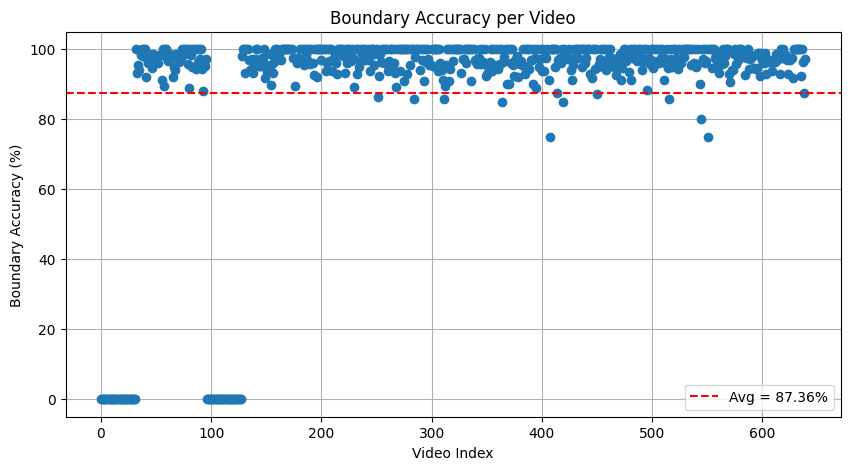

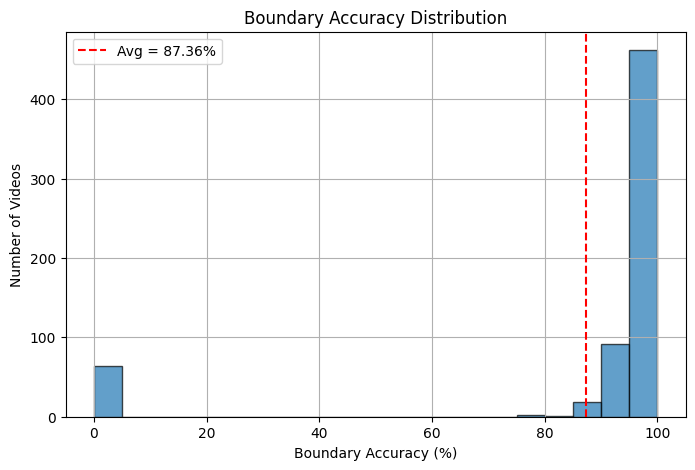

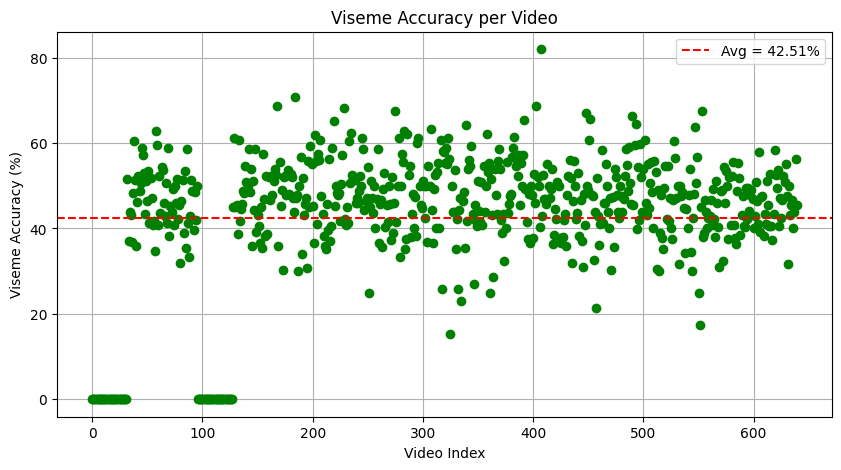

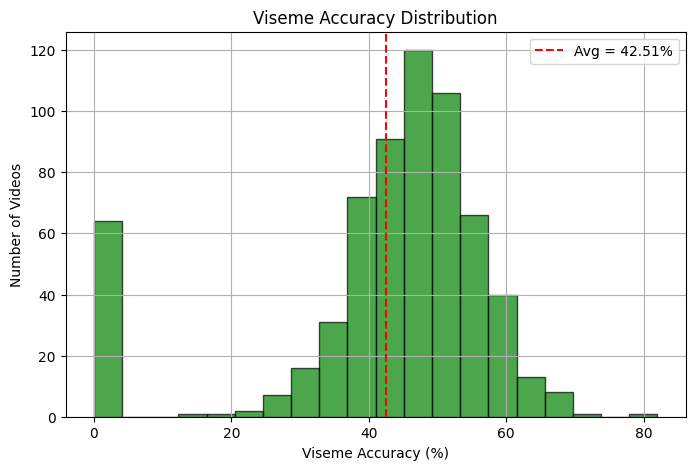

In [27]:
import os
import glob
import torch
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

# --- CONFIG ---
BATCH_SIZE = 128  # Each .npz file contains 32 videos
BOUNDARY_TOKENS = {"<sow>", "<eow>"}
IGNORE_TOKENS = {"<sos>", "<eos>", "<sow>", "<eow>", "<space>", "<sil>", "<pad>"}

# === 1. Detect Validation Files ===
# Count how many *_videos_compressed.npz files exist in the validation folder
val_files = sorted(glob.glob(os.path.join(BATCH_FOLDER, "*_videos_compressed.npz")))
NUM_TEST_VIDEOS = len(val_files) * 32  # 32 videos per file
print(f"Found {len(val_files)} validation files → {NUM_TEST_VIDEOS} videos to evaluate.")

# === 2. Load Latest Model ===
saved_models = glob.glob(os.path.join(MODEL_SAVE_FOLDER, "epoch_*.pt"))
if not saved_models:
    raise FileNotFoundError("No saved models found in MODEL_SAVE_FOLDER")

latest_model = max(saved_models, key=lambda x: int(x.split('_')[-1].split('.')[0]))
print(f"🔄 Using latest model: {latest_model}")

checkpoint = torch.load(latest_model, map_location=device)
model = LipReadingModel().to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# === 3. Accuracy Functions ===
def fast_boundary_accuracy(pred_ids, true_ids):
    """
    Boundary match accuracy (%): compares <sow>/<eow> positions between prediction and ground truth.
    Prepends <sos> to BOTH sequences to ensure alignment.
    """
    pred_tokens = ["<sos>"] + [INDEX_TO_TOKEN[i] for i in pred_ids]
    true_tokens = ["<sos>"] + [INDEX_TO_TOKEN[i] for i in true_ids]

    pred_boundaries = {i for i, t in enumerate(pred_tokens) if t in BOUNDARY_TOKENS}
    true_boundaries = {i for i, t in enumerate(true_tokens) if t in BOUNDARY_TOKENS}

    if not true_boundaries:
        return 0.0
    return round((len(pred_boundaries & true_boundaries) / len(true_boundaries)) * 100, 2)

def fast_viseme_accuracy(pred_ids, true_ids):
    """
    Viseme match accuracy (%): compares viseme tokens ignoring special tokens.
    """
    pred_tokens = [INDEX_TO_TOKEN[i] for i in pred_ids]
    true_tokens = [INDEX_TO_TOKEN[i] for i in true_ids]

    matches = 0
    total = 0
    for p, t in zip(pred_tokens, true_tokens):
        if p in IGNORE_TOKENS or t in IGNORE_TOKENS:
            continue
        total += 1
        if p == t:
            matches += 1
    if total == 0:
        return 0.0
    return round((matches / total) * 100, 2)

# === 4. Collect Results (No Preallocation) ===
boundary_results = []
viseme_results = []

# === 5. Load and Predict in Large Batches ===
with torch.no_grad():
    with torch.amp.autocast("cuda", enabled=True):
        for batch_start in tqdm(range(0, NUM_TEST_VIDEOS, BATCH_SIZE), desc="Eval"):
            # Index files sequentially (validation starts at 0)
            video_tensor, viseme_tensor = load_and_prepare_batch(batch_start)
            if video_tensor is None:
                continue  # Skip missing batches safely

            # Move tensors to GPU
            video_tensor = video_tensor.to(device)
            viseme_tensor = viseme_tensor.to(device)

            # Predict viseme tokens
            logits = model(video_tensor, viseme_tensor[:, :-1])
            pred_ids = logits.argmax(dim=-1).cpu().numpy()
            true_ids = viseme_tensor[:, 1:].cpu().numpy()

            # Calculate accuracies for each video
            for i in range(video_tensor.size(0)):
                boundary_acc = fast_boundary_accuracy(pred_ids[i], true_ids[i])
                viseme_acc = fast_viseme_accuracy(pred_ids[i], true_ids[i])
                vid_index = batch_start + i
                boundary_results.append([vid_index, boundary_acc])
                viseme_results.append([vid_index, viseme_acc])

# Convert results to arrays
boundary_matrix = np.array(boundary_results)
viseme_matrix = np.array(viseme_results)

# === 6. Save Results ===
np.save(os.path.join(MODEL_SAVE_FOLDER, "boundary_match_results.npy"), boundary_matrix)
np.save(os.path.join(MODEL_SAVE_FOLDER, "viseme_match_results.npy"), viseme_matrix)

# === 7. Plot Boundary Accuracy ===
video_indices = boundary_matrix[:, 0]
boundary_accs = boundary_matrix[:, 1]
boundary_avg = np.mean(boundary_accs)

plt.figure(figsize=(10, 5))
plt.plot(video_indices, boundary_accs, marker='o', linestyle='none')
plt.axhline(boundary_avg, color='red', linestyle='--', label=f'Avg = {boundary_avg:.2f}%')
plt.title("Boundary Accuracy per Video")
plt.xlabel("Video Index")
plt.ylabel("Boundary Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(boundary_accs, bins=20, alpha=0.7, edgecolor='black')
plt.axvline(boundary_avg, color='red', linestyle='--', label=f'Avg = {boundary_avg:.2f}%')
plt.title("Boundary Accuracy Distribution")
plt.xlabel("Boundary Accuracy (%)")
plt.ylabel("Number of Videos")
plt.legend()
plt.grid(True)
plt.show()

# === 8. Plot Viseme Accuracy ===
viseme_accs = viseme_matrix[:, 1]
viseme_avg = np.mean(viseme_accs)

plt.figure(figsize=(10, 5))
plt.plot(video_indices, viseme_accs, marker='o', color='green', linestyle='none')
plt.axhline(viseme_avg, color='red', linestyle='--', label=f'Avg = {viseme_avg:.2f}%')
plt.title("Viseme Accuracy per Video")
plt.xlabel("Video Index")
plt.ylabel("Viseme Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(viseme_accs, bins=20, alpha=0.7, edgecolor='black', color='green')
plt.axvline(viseme_avg, color='red', linestyle='--', label=f'Avg = {viseme_avg:.2f}%')
plt.title("Viseme Accuracy Distribution")
plt.xlabel("Viseme Accuracy (%)")
plt.ylabel("Number of Videos")
plt.legend()
plt.grid(True)
plt.show()


In [28]:
# === 7. Plot Boundary Accuracy and Save ===
video_indices = boundary_matrix[:, 0]
boundary_accs = boundary_matrix[:, 1]
boundary_avg = np.mean(boundary_accs)

# Line plot
plt.figure(figsize=(10, 5))
plt.plot(video_indices, boundary_accs, marker='o', linestyle='none')
plt.axhline(boundary_avg, color='red', linestyle='--', label=f'Avg = {boundary_avg:.2f}%')
plt.title("Boundary Accuracy per Video")
plt.xlabel("Video Index")
plt.ylabel("Boundary Accuracy (%)")
plt.legend()
plt.grid(True)
boundary_plot_path = os.path.join(MODEL_SAVE_FOLDER, "boundary_accuracy_plot.png")
plt.savefig(boundary_plot_path, dpi=300, bbox_inches='tight')
plt.close()

# Histogram
plt.figure(figsize=(8, 5))
plt.hist(boundary_accs, bins=20, alpha=0.7, edgecolor='black')
plt.axvline(boundary_avg, color='red', linestyle='--', label=f'Avg = {boundary_avg:.2f}%')
plt.title("Boundary Accuracy Distribution")
plt.xlabel("Boundary Accuracy (%)")
plt.ylabel("Number of Videos")
plt.legend()
plt.grid(True)
boundary_hist_path = os.path.join(MODEL_SAVE_FOLDER, "boundary_accuracy_hist.png")
plt.savefig(boundary_hist_path, dpi=300, bbox_inches='tight')
plt.close()

# === 8. Plot Viseme Accuracy and Save ===
viseme_accs = viseme_matrix[:, 1]
viseme_avg = np.mean(viseme_accs)

# Line plot
plt.figure(figsize=(10, 5))
plt.plot(video_indices, viseme_accs, marker='o', color='green', linestyle='none')
plt.axhline(viseme_avg, color='red', linestyle='--', label=f'Avg = {viseme_avg:.2f}%')
plt.title("Viseme Accuracy per Video")
plt.xlabel("Video Index")
plt.ylabel("Viseme Accuracy (%)")
plt.legend()
plt.grid(True)
viseme_plot_path = os.path.join(MODEL_SAVE_FOLDER, "viseme_accuracy_plot.png")
plt.savefig(viseme_plot_path, dpi=300, bbox_inches='tight')
plt.close()

# Histogram
plt.figure(figsize=(8, 5))
plt.hist(viseme_accs, bins=20, alpha=0.7, edgecolor='black', color='green')
plt.axvline(viseme_avg, color='red', linestyle='--', label=f'Avg = {viseme_avg:.2f}%')
plt.title("Viseme Accuracy Distribution")
plt.xlabel("Viseme Accuracy (%)")
plt.ylabel("Number of Videos")
plt.legend()
plt.grid(True)
viseme_hist_path = os.path.join(MODEL_SAVE_FOLDER, "viseme_accuracy_hist.png")
plt.savefig(viseme_hist_path, dpi=300, bbox_inches='tight')
plt.close()

print(f"✅ Plots saved to:\n{boundary_plot_path}\n{boundary_hist_path}\n{viseme_plot_path}\n{viseme_hist_path}")


✅ Plots saved to:
/content/drive/My Drive/majd/Viso_Speak_model/boundary_accuracy_plot.png
/content/drive/My Drive/majd/Viso_Speak_model/boundary_accuracy_hist.png
/content/drive/My Drive/majd/Viso_Speak_model/viseme_accuracy_plot.png
/content/drive/My Drive/majd/Viso_Speak_model/viseme_accuracy_hist.png
